# FMNIST → KMNIST OOD Multi-Seed (Low-Rank Gaussian)

One model evaluated across multiple random seeds:

- Model: Low-Rank Gaussian BNN (multiclass)
- ID: FashionMNIST test
- OOD: KMNIST test
- Metrics: `MI`, `EU_var`, `sum_Ck`, `neg_MSP`

Outputs: per-seed checkpoints, per-seed metrics CSV, aggregated mean±std CSV.

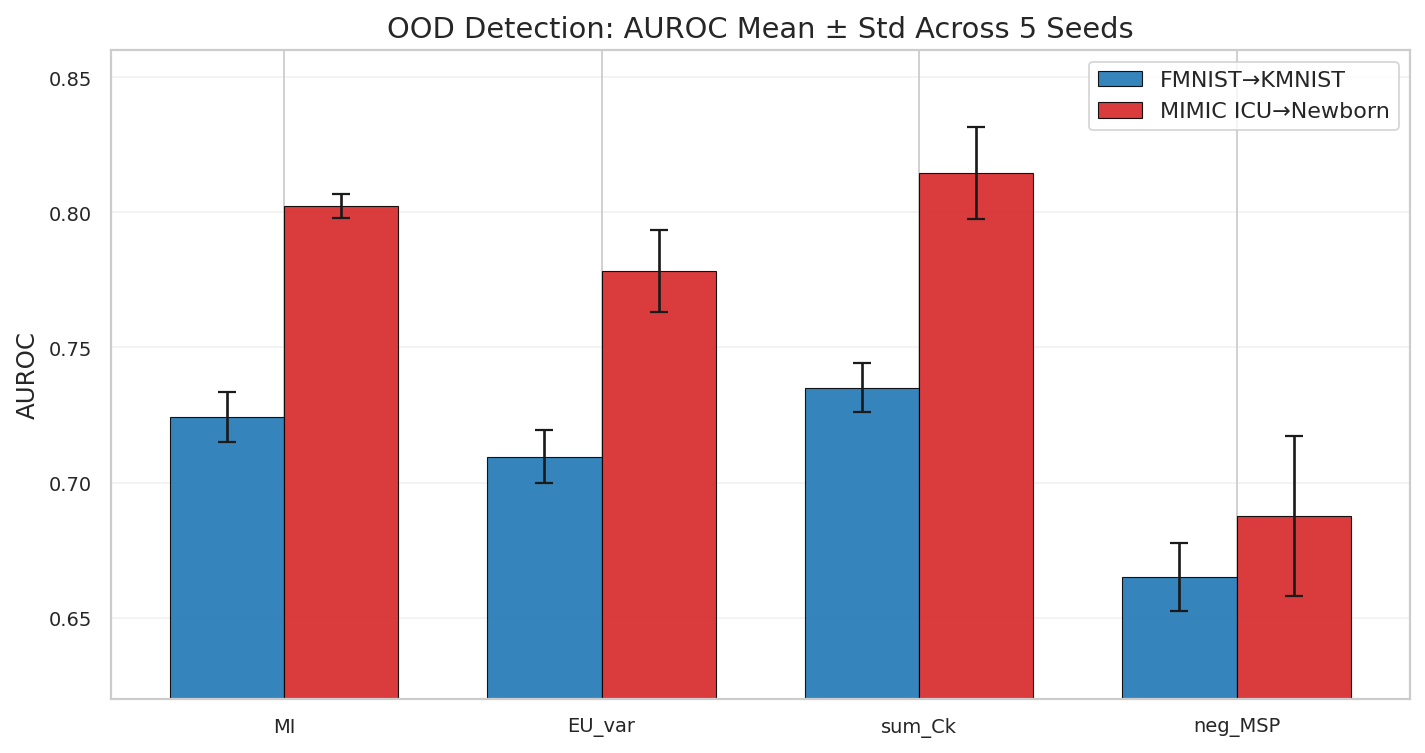

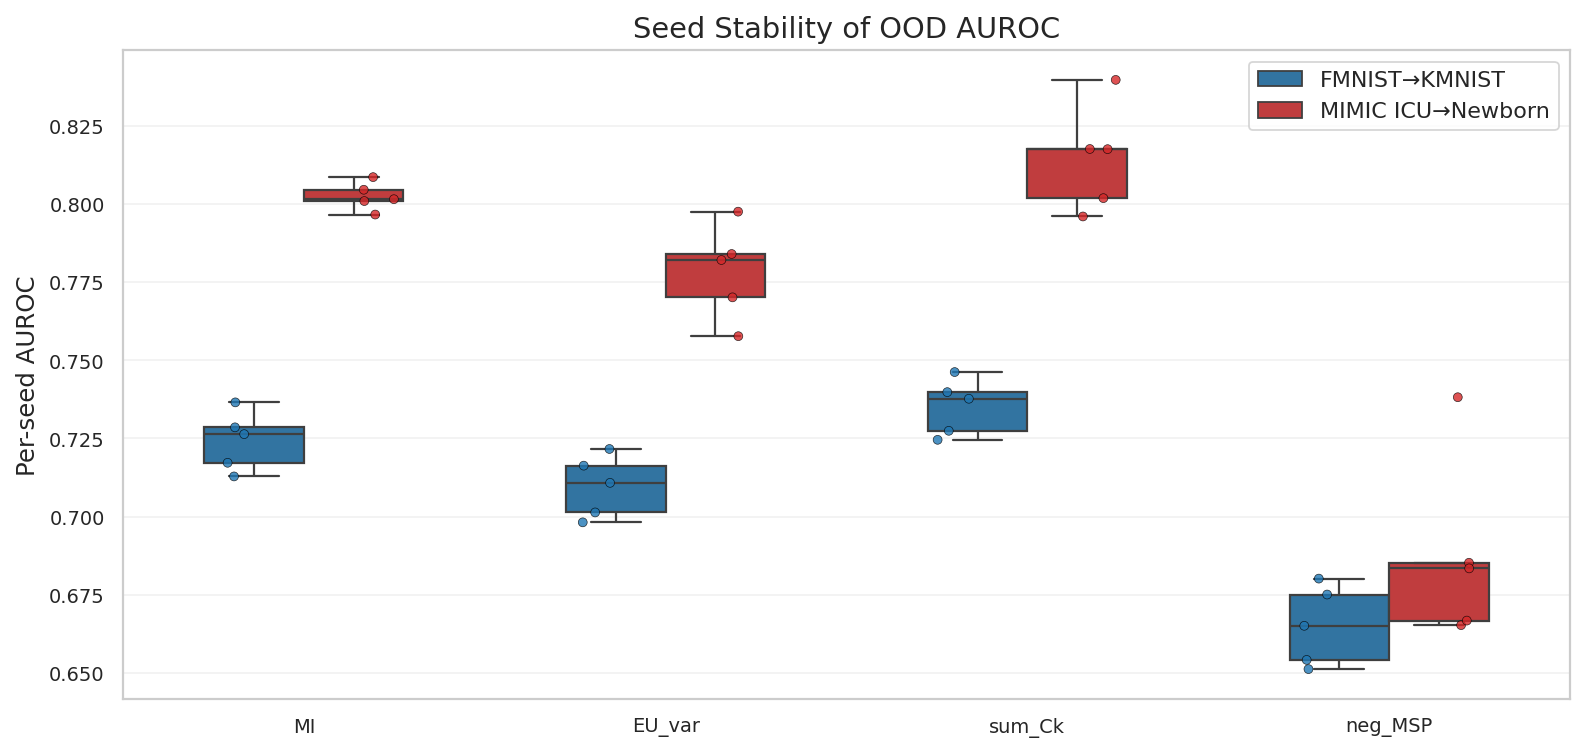

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

root = Path("results_csv")
fm_agg  = pd.read_csv(root / "fmnist_kmnist_lowrank_gauss_multiseed_agg.csv")
mi_agg  = pd.read_csv(root / "mimic_lowrank_gauss_multiseed_agg.csv")
fm_seed = pd.read_csv(root / "fmnist_kmnist_lowrank_gauss_multiseed_per_seed.csv")
mi_seed = pd.read_csv(root / "mimic_lowrank_gauss_multiseed_per_seed.csv")

fm_agg["dataset"]  = "FMNIST→KMNIST"
mi_agg["dataset"]  = "MIMIC ICU→Newborn"
fm_seed["dataset"] = "FMNIST→KMNIST"
mi_seed["dataset"] = "MIMIC ICU→Newborn"

agg  = pd.concat([fm_agg, mi_agg], ignore_index=True)
seed = pd.concat([fm_seed, mi_seed], ignore_index=True)

preferred_order = ["MI", "EU_var", "sum_Ck", "neg_MSP", "C1"]
common_metrics = [m for m in preferred_order if m in set(fm_agg.metric) and m in set(mi_agg.metric)]
all_metrics = [m for m in preferred_order if m in set(seed.metric)]

palette = {
    "FMNIST→KMNIST": "#1f77b4",
    "MIMIC ICU→Newborn": "#d62728",
}

# Figure 1: AUROC mean ± std
fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(common_metrics))
w = 0.36

for i, ds in enumerate(["FMNIST→KMNIST", "MIMIC ICU→Newborn"]):
    d = agg[(agg.dataset == ds) & (agg.metric.isin(common_metrics))].set_index("metric").loc[common_metrics]
    ax.bar(
        x + (i - 0.5) * w,
        d["AUROC_mean"].values,
        yerr=d["AUROC_std"].values,
        capsize=4,
        width=w,
        label=ds,
        color=palette[ds],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.5,
    )

ax.set_xticks(x)
ax.set_xticklabels(common_metrics)
ax.set_ylim(0.62, 0.86)
ax.set_ylabel("AUROC")
ax.set_title("OOD Detection: AUROC Mean ± Std Across 5 Seeds")
ax.legend(frameon=True)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig("figs/fig1_auroc_mean_std.png")
plt.show()

# Figure 2: Seed-level AUROC stability
fig, ax = plt.subplots(figsize=(10, 4.8))
d2 = seed[seed.metric.isin(common_metrics)].copy()

sns.boxplot(
    data=d2, x="metric", y="auroc", hue="dataset",
    order=common_metrics, palette=palette, width=0.55, fliersize=0, ax=ax
)
sns.stripplot(
    data=d2, x="metric", y="auroc", hue="dataset",
    order=common_metrics, dodge=True, palette=palette, ax=ax,
    size=4, alpha=0.8, linewidth=0.3, edgecolor="black"
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="", frameon=True, loc="best")
ax.set_ylabel("Per-seed AUROC")
ax.set_xlabel("")
ax.set_title("Seed Stability of OOD AUROC")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig("figs/fig2_seed_stability.png")
plt.show()

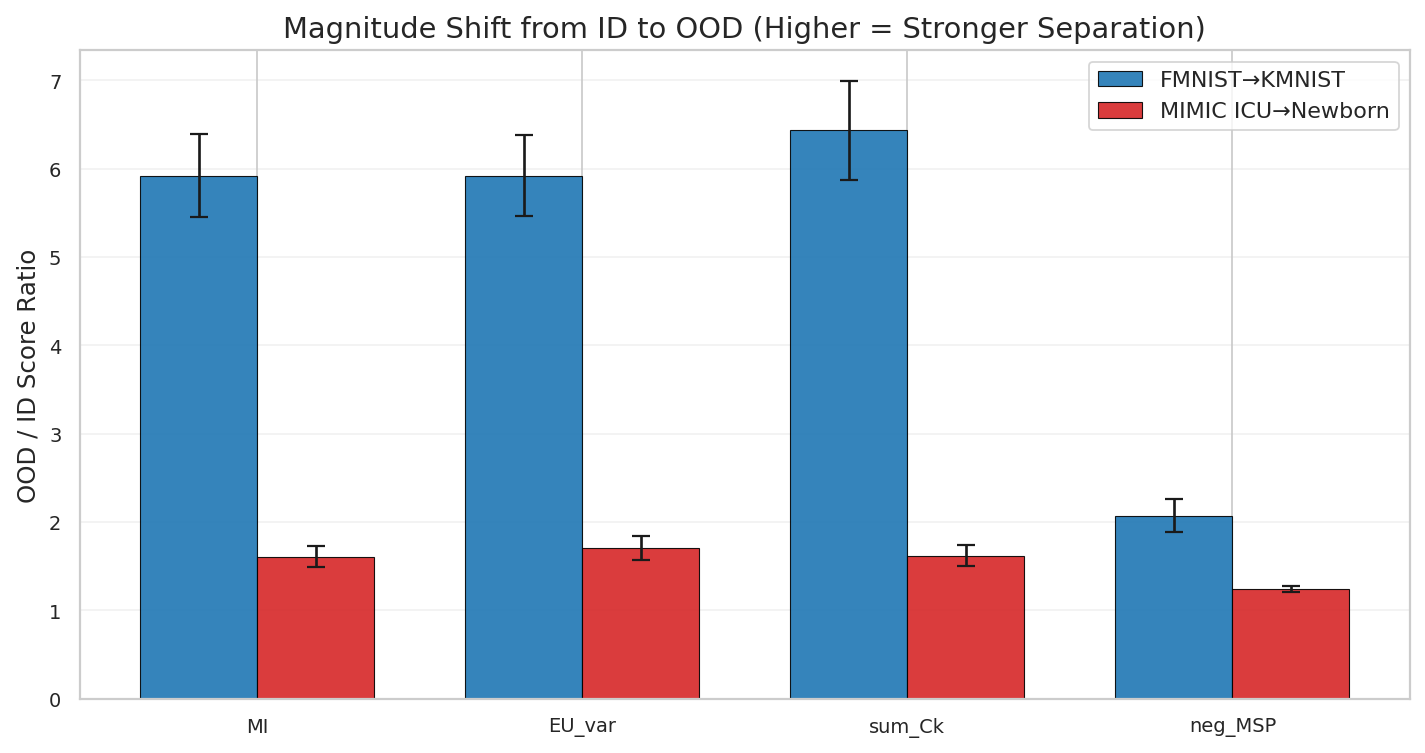

In [2]:
# ---------------- Figure 3: OOD/ID ratio (mean ± std over seeds) ----------------
ratio = (
    seed[seed.metric.isin(common_metrics)]
    .groupby(["dataset", "metric"])["ood_to_id_ratio"]
    .agg(ratio_mean="mean", ratio_std="std")
    .reset_index()
    .set_index(["dataset", "metric"])
)

fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(common_metrics))
w = 0.36

for i, ds in enumerate(["FMNIST→KMNIST", "MIMIC ICU→Newborn"]):
    d = ratio.loc[ds].reindex(common_metrics)
    ax.bar(
        x + (i - 0.5) * w,
        d["ratio_mean"].values,
        yerr=d["ratio_std"].values,
        capsize=4,
        width=w,
        label=ds,
        color=palette[ds],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.5,
    )

ax.set_xticks(x)
ax.set_xticklabels(common_metrics)
ax.set_ylabel("OOD / ID Score Ratio")
ax.set_title("Magnitude Shift from ID to OOD (Higher = Stronger Separation)")
ax.legend(frameon=True)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig("figs/fig3_ood_id_ratio.png")
plt.show()
